#Customer Churn and CLV Analysis

##Problem Statement
The objective of this project is to predict customer churn and identify high-value customers at risk.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data (4).csv


In [105]:
df=pd.read_csv("data (4).csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Overview
The dataset contains customer demographics, service details, and churn status.

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [107]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [108]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [109]:
df.shape

(7043, 21)

### Observations:
- Dataset has 7043 rows
- Target variable: Churn
- Mix of categorical and numerical variables

#Data Cleaning

In [110]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

In [111]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

#EDA

1. Countplot for checking class imbalance

In [112]:
churn_counts = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts)

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


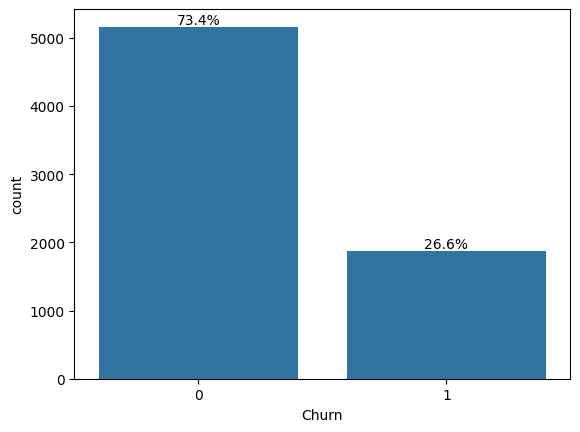

In [113]:
ax = sns.countplot(x='Churn', data=df)

total = len(df)

for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

### Observations:

- Approximately 73% of customers did not churn, while 27% churned.
- The dataset is imbalanced, with significantly more non-churn cases.
- This implies that accuracy alone is not a reliable metric; metrics like ROC-AUC and precision-recall should be used.

2. Plotting histogram to see distribution of Tenure and Monthly Charges.

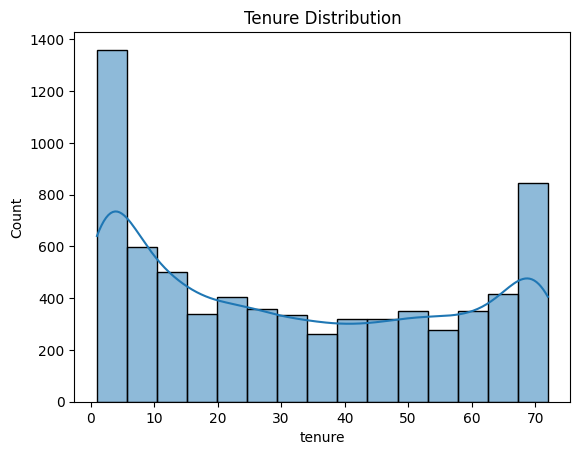

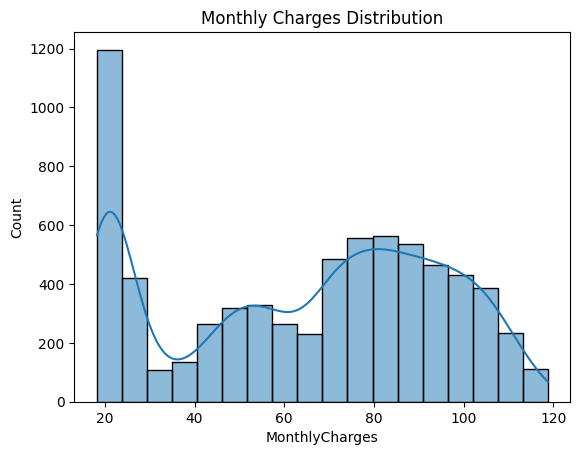

In [114]:
plt.figure()
sns.histplot(df['tenure'], kde=True)
plt.title("Tenure Distribution")
plt.show()

plt.figure()
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

###Observations:


*   Tenure distribution is right-skewed with most customers with low tenure, indicating a large number of recent/new customers.


*   Monthly charges shows multiple peaks, suggesting presence of different pricing plan.
*   Customers with higher monthly charges may show different churn behaviour from customers with low-paying plans.






3. Countplot to check how many customers churned vs stayed in each contract type.

<Axes: xlabel='Contract'>

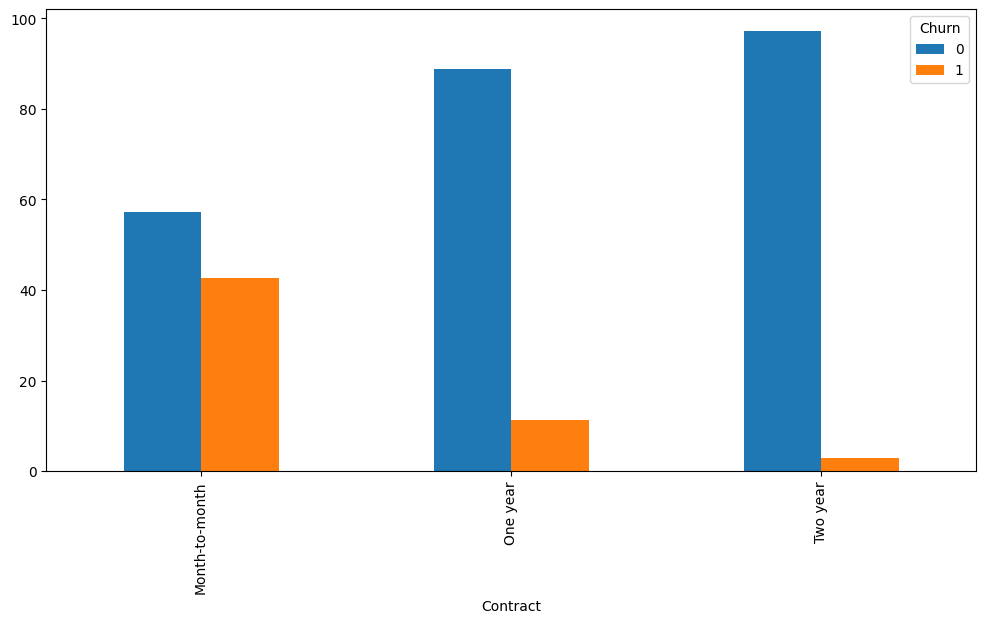

In [115]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=False,figsize=(12,6))

### Observations:

- Customers with month-to-month contracts show significantly higher churn rates.
- Long-term contracts (one-year and two-year) have much lower churn.
- This suggests that customer commitment reduces churn probability.

Customers on month-to-month contracts face lower switching costs, making them more likely to churn compared to long-term contract customers.



#Feature Engineering

Drop useless column- customerID

In [116]:
df.drop('customerID', axis=1, inplace=True)

Encode categorical features

In [117]:
df = pd.get_dummies(df, drop_first=True, dtype=int)

##Correlation

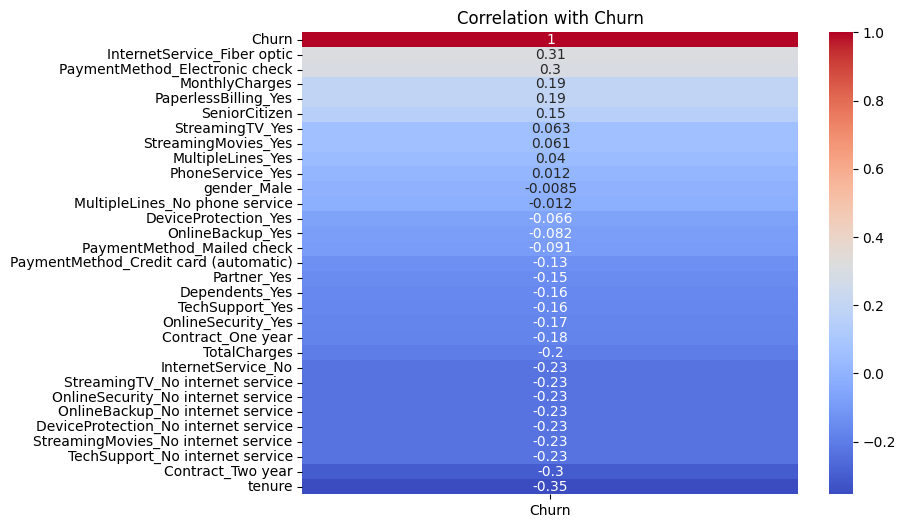

In [118]:
corr = df.corr()['Churn'].sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.heatmap(corr.to_frame(), annot=True, cmap='coolwarm')
plt.title("Correlation with Churn")
plt.show()

###Observation:


*   Customers using fibre optic internet service are more likely to churn than non fibre optic users.

* Customers who pay using electronic check are more likely to churn than customers who pay using other methods.

*   Customers having two years contract are more likely to not churn than customers having other contracts.
*  Customers having longer tenure are more likely not to churn.



#Creating train and test samples

In [119]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Model 1: Logistic Regression

In [120]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr=lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [121]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, precision_score, recall_score

print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))
print(classification_report(y_test, y_pred_lr))

Logistic Regression:
Accuracy: 0.7874911158493249
ROC-AUC: 0.8321357760740484
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



#Model 2: Random Forest

In [122]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [123]:
print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))
print(classification_report(y_test, y_pred_rf))

Random Forest:
Accuracy: 0.7896233120113717
ROC-AUC: 0.818467834198715
              precision    recall  f1-score   support

           0       0.83      0.91      0.86      1033
           1       0.64      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



In [124]:
results=pd.DataFrame({'Model':['Logistic Regression','Random Forest'],
                      'Accuracy':[accuracy_score(y_test, y_pred_lr),accuracy_score(y_test, y_pred_rf)],
                      'ROC-AUC':[roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]),roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])],
                      'Precision':[precision_score(y_test, y_pred_lr),precision_score(y_test, y_pred_rf)],
                      'Recall':[recall_score(y_test, y_pred_lr),recall_score(y_test, y_pred_rf)],
                      })
results

,Model,Accuracy,ROC-AUC,Precision,Recall
0,Logistic Regression,0.787491,0.832136,0.620579,0.516043
1,Random Forest,0.789623,0.818468,0.642336,0.470588


###Observations:
Logistic Regression Model is preferred over random Forest Model, beacuse:

*   It has better ROC-AUC score.
*   It has better recall, which is particularly important because goal is catching more churn customers.

#SHapley Additive exPlanations (SHAP)

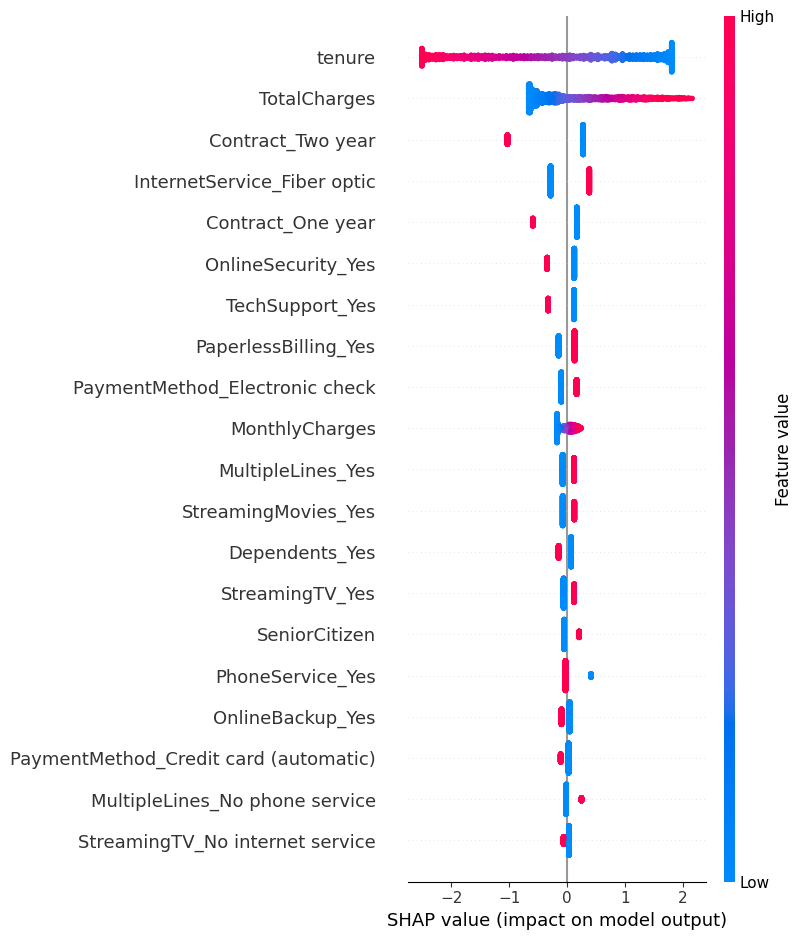

In [125]:
import shap

explainer = shap.LinearExplainer(lr,X_train)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

##Observations:

- Customers with low tenure are more likely to churn, while long-term customers are more stable.
- Customers with higher total charges tend to have higher churn probability, possibly due to higher pricing or dissatisfaction with expensive plans.
- Customers with month-to-month contracts are more likely to churn, while long-term contracts reduce churn.
- Fiber optic users show higher churn risk.
- Customers with online security and tech support are less likely to churn.
- Higher monthly charges slightly increase churn probability.

#Customer Lifetime Value :(CLV)
CLV is an estimate of the total revenue generated by a customer over their lifetime. It helps prioritize high-value customers.


In [126]:
df['CLV'] = df['MonthlyCharges'] * df['tenure']

#Segmentation
K-means (supporting analysis)

In [127]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['Segment'] = kmeans.fit_predict(df[['CLV','MonthlyCharges', 'tenure']])

In [128]:
cluster_summary = df.groupby('Segment')['CLV'].mean().sort_values()
print(cluster_summary)

Segment
1     684.595028
2    3269.660296
0    6291.630310
Name: CLV, dtype: float64


In [129]:
labels = ['Low Value', 'Medium Value', 'High Value']

cluster_map = dict(zip(cluster_summary.index, labels))

In [130]:
df['Segment_Label'] = df['Segment'].map(cluster_map)

Customers were segmented into three groups using K-Means clustering based on CLV.

- Segment 1: Low Value customers  
- Segment 2: Medium Value customers  
- Segment 0: High Value customers  

This segmentation helps identify which customers contribute most to revenue and should be prioritized for retention.

#Final Dataset
By combining churn probability with CLV, we can identify high-value customers at risk and prioritize retention strategies.



In [133]:
df_final = X_test.copy()
df_final['Churn_Prob'] = lr.predict_proba(X_test)[:,1]
df_final['CLV'] = df.loc[X_test.index, 'CLV']
df_final['Segment'] = df.loc[X_test.index, 'Segment']
df_final['Segment_Label'] = df.loc[X_test.index, 'Segment_Label']

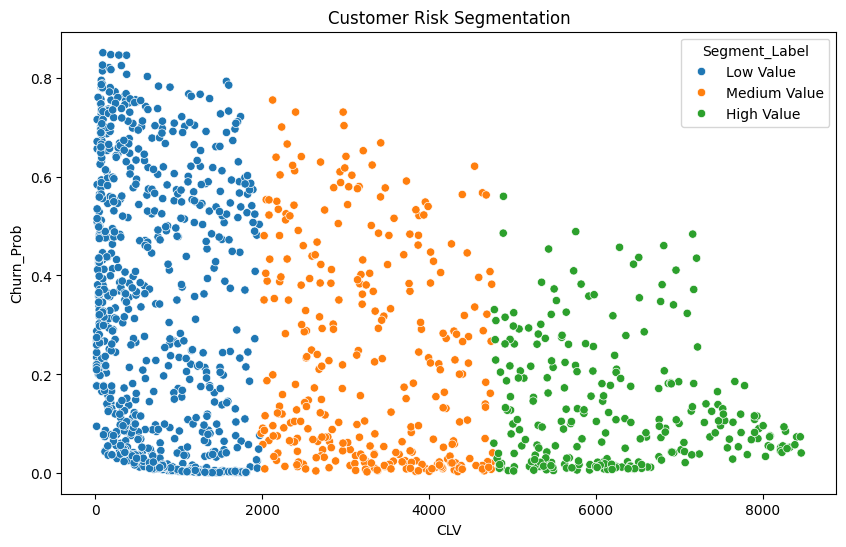

In [134]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_final,
    x='CLV',
    y='Churn_Prob',
    hue='Segment_Label'
)

plt.title("Customer Risk Segmentation")
plt.show()

##Expanded Segmentation into categories

In [135]:
df_final['Category'] = 'Low Risk - Low Value'

df_final.loc[
    (df_final['Churn_Prob'] > 0.6) & (df_final['CLV'] > df_final['CLV'].median()),
    'Category'
] = 'High Risk - High Value'

df_final.loc[
    (df_final['Churn_Prob'] > 0.6) & (df_final['CLV'] <= df_final['CLV'].median()),
    'Category'
] = 'High Risk - Low Value'

df_final.loc[
    (df_final['Churn_Prob'] <= 0.6) & (df_final['CLV'] > df_final['CLV'].median()),
    'Category'
] = 'Low Risk - High Value'

<Axes: xlabel='CLV', ylabel='Churn_Prob'>

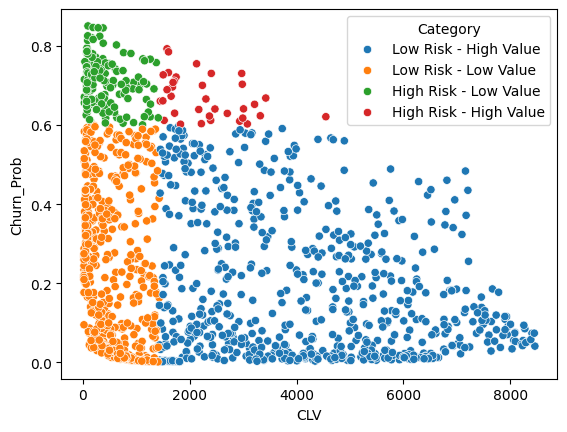

In [136]:
sns.scatterplot(
    data=df_final,
    x='CLV',
    y='Churn_Prob',
    hue='Category'
)

Customers with high CLV and high churn risk are the most important group, since losing them would cause the biggest loss.

Segmentation helps us focus on the right customers by considering both their value and their risk of leaving.

In [137]:
df_final['Category'].value_counts()

,count
Category,
Low Risk - High Value,668
Low Risk - Low Value,551
High Risk - Low Value,153
High Risk - High Value,35


Approximately 2.5% of customers fall into the High Risk–High Value segment, representing the most critical group for retention.

In [140]:
df_final[df_final['Category'] == 'High Risk - High Value'].sort_values(by='Churn_Prob', ascending=False).head(10)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Prob,CLV,Segment,Segment_Label,Category
5213,1,17,92.55,1614.70,0,1,0,1,0,1,...,0,1,0,1,0,0.792693,1573.35,1,Low Value,High Risk - High Value
1725,1,17,94.20,1608.15,0,0,0,1,0,1,...,0,1,0,1,0,0.784955,1601.40,1,Low Value,High Risk - High Value
1485,1,22,96.70,2082.95,1,0,0,1,0,1,...,0,1,0,1,0,0.754804,2127.40,2,Medium Value,High Risk - High Value
1456,0,16,100.00,1534.75,0,1,0,1,0,1,...,0,1,0,1,0,0.732532,1600.00,1,Low Value,High Risk - High Value
5072,1,23,104.45,2184.85,1,1,0,1,0,1,...,0,1,0,1,0,0.730454,2402.35,2,Medium Value,High Risk - High Value


These are the target customers.

##Business Decisions:
- High Risk + High Value: Offer discounts or loyalty plans
- High Risk + Low Value: Low cost retention strategies (emails, offers)
- Low Risk + High Value: Sell more expensive items
- Low Risk + Low Value: Minimal Intervention